In [32]:
import imageio
from skimage.morphology import erosion

from segmentation_metrics import SegmentationMetrics
from graph_metrics import GraphMetrics

import matplotlib.pyplot as plt
import numpy as np
from skimage.filters import threshold_otsu, threshold_mean
from skimage.morphology import erosion
from skimage import restoration
from skimage.transform import resize
import copy
from PIL import Image
import contextlib
import pickle

import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import transforms



import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import transforms

from groupy.gconv.pytorch_gconv.splitgconv2d import P4ConvZ2, P4ConvP4
from groupy.gconv.pytorch_gconv import P4MConvZ2, P4MConvP4M
from groupy.gconv.pytorch_gconv.pooling import plane_group_spatial_max_pooling

from skimage.filters import threshold_minimum, threshold_mean

class NNet(nn.Module):
    def __init__(self, in_channels, out_channels):
        super(NNet, self).__init__()
        

        self.conv1 = P4MConvZ2(in_channels, 32, kernel_size=3, stride=1, padding=1)
        self.conv2 = P4MConvP4M(32, 32, kernel_size=3, stride=1, padding=1)

        self.conv3 = P4MConvP4M(32, 64, kernel_size=3, stride=1, padding=1)
        self.conv4 = P4MConvP4M(64, 128, kernel_size=3, stride=1, padding=1)

        self.conv5 = P4MConvP4M(128, 64, kernel_size=3, padding=1)
        self.conv6 = P4MConvP4M(64, 32, kernel_size=3, padding=1)

        self.convt = nn.ConvTranspose2d(32*8, out_channels, kernel_size=2, stride=2, output_padding=0)


    def forward(self, x):
        x = F.relu(self.conv1(x))
        x = F.relu(self.conv2(x))
        x = plane_group_spatial_max_pooling(x, 2, 2)
        x = F.relu(self.conv3(x))
        x = F.relu(self.conv4(x))
        x = F.relu(self.conv5(x))
        x = F.relu(self.conv6(x))
        xs = x.size()
        x = x.view(xs[0], xs[1] * xs[2], xs[3], xs[4])
#         x = F.avg_pool2d(x, 2, 2)
        x = self.convt(x)

        return x


def load_models():
    p4m = NNet(1, 1)
    p4m.load_state_dict(torch.load('NNet_groupy_p4m_v2_VecAdam.pth'))

#     p4m_adaptive = NNet(1, 1)
#     p4m_adaptive.load_state_dict(torch.load('NNet_groupy_p4m_v2_VecAdam_adaptive.pth'))

    return p4m



def process_op(imgpath, model):
    img = imageio.imread(imgpath)
    img = resize(img, (32, 32), anti_aliasing=True)
    image = Image.fromarray(img)
#     image = Image.open(imgpath)
    transform = transforms.Compose([
        transforms.ToTensor(),
    ])

    image = transform(image)
    image = image.unsqueeze(0)  # Add batch dimension

    model.eval()
    with torch.no_grad():
        output = model(image)

    # Convert the output to probabilities by applying the sigmoid activation
    output_probs = torch.sigmoid(output)

    # Convert tensors to numpy arrays for visualization
    output_probs_np = output_probs.cpu().squeeze().numpy()

    norm = (output_probs_np - output_probs_np.min()) / (output_probs_np.max() - output_probs_np.min())

    rb = restoration.rolling_ball(norm)
    subt = norm - rb

#     thr = threshold_otsu(subt) # sted data
#     thr = threshold_minimum(subt)
    thr = threshold_mean(subt) # confocal data

    subt2 = copy.deepcopy(subt)

    subt2[subt < thr] = 0.
    subt2[subt >= thr] = 255.

    return subt2

In [ ]:
from skimage.morphology import skeletonize
import skimage.io as io

model = load_models()




imgpath = '/localhome/asa420/MIAL/data/confocal-data/Climp/er_mean/climp12_er_mean.png'
op = process_op(imgpath, model) / 255
skel = (skeletonize(op) * 255).astype('uint8')
io.imsave(f'/localhome/asa420/MIAL/data/sted-data/vess_enh_unet/climp/blur_skel/C{seq}_decon_t0{frame:02d}_ch00_skel.png', skel)


In [27]:
# from skimage.morphology import skeletonize
# import skimage.io as io

# model = load_models()


# for seq in range(1, 17):
# #     try:
#         for frame in range(100):
#             imgpath = f'/localhome/asa420/MIAL/data/sted-data/climp/std/C{seq}_decon_t0{frame:02d}_ch00_std.png'
#             op = process_op(imgpath, model) / 255
#             skel = (skeletonize(op) * 255).astype('uint8')
#             io.imsave(f'/localhome/asa420/MIAL/data/sted-data/climp/skel/C{seq}_decon_t0{frame:02d}_ch00_skel.png', skel)
#     except:
#         pass
# #     try:
# #         for frame in range(100):
# #             imgpath = f'/localhome/asa420/MIAL/data/sted-data/Control/std/Ct{seq}_decon_t0{frame:02d}_ch00_std.png'
# #             op = process_op(imgpath, model) / 255
# #             skel = (skeletonize(op) * 255).astype('uint8')
# #             io.imsave(f'/localhome/asa420/MIAL/data/sted-data/Control/skel/Ct{seq}_decon_t0{frame:02d}_ch00_skel.png', skel)
# #     except:
# #         pass
    
# #     try:
# #         for frame in range(100):
# #             imgpath = f'/localhome/asa420/MIAL/data/sted-data/RTN/std/R{seq}_decon_t0{frame:02d}_ch00_std.png'
# #             op = process_op(imgpath, model) / 255
# #             skel = (skeletonize(op) * 255).astype('uint8')
# #             io.imsave(f'/localhome/asa420/MIAL/data/sted-data/RTN/skel/R{seq}_decon_t0{frame:02d}_ch00_skel.png', skel)
# #     except:
# #         pass

In [29]:
from skimage.morphology import skeletonize
import skimage.io as io

model = load_models()

for seq in range(2, 17):
    try:
        for frame in range(100):
            imgpath = f'/localhome/asa420/MIAL/data/sted-data/climp/std/C{seq}_decon_t0{frame:02d}_ch00_std.png'
            op = process_op(imgpath, model) / 255
            skel = (skeletonize(op) * 255).astype('uint8')
            io.imsave(f'/localhome/asa420/MIAL/data/sted-data/vess_enh_unet/climp/blur_skel/C{seq}_decon_t0{frame:02d}_ch00_skel.png', skel)
    except:
        pass

In [30]:

for seq in range(1, 17):
    try:
        for frame in range(100):
            imgpath = f'/localhome/asa420/MIAL/data/sted-data/control/std/Ct{seq}_decon_t0{frame:02d}_ch00_std.png'
            op = process_op(imgpath, model) / 255
            skel = (skeletonize(op) * 255).astype('uint8')
            io.imsave(f'/localhome/asa420/MIAL/data/sted-data/vess_enh_unet/control/blur_skel/Ct{seq}_decon_t0{frame:02d}_ch00_skel.png', skel)
    except:
        pass

In [31]:

for seq in range(1, 17):
    try:
        for frame in range(100):
            imgpath = f'/localhome/asa420/MIAL/data/sted-data/rtn/std/R{seq}_decon_t0{frame:02d}_ch00_std.png'
            op = process_op(imgpath, model) / 255
            skel = (skeletonize(op) * 255).astype('uint8')
            io.imsave(f'/localhome/asa420/MIAL/data/sted-data/vess_enh_unet/rtn/blur_skel/R{seq}_decon_t0{frame:02d}_ch00_skel.png', skel)
    except:
        pass

In [19]:
from skimage.morphology import skeletonize
import skimage.io as io

model = load_models()


# for seq in range(5, 8):
#     for frame in range(100):
#         imgpath = f'/localhome/asa420/MIAL/data/sted-data/control/std/Ct{seq}_decon_t0{frame:02d}_ch00_std.png'
#         op = process_op(imgpath, model) / 255
#         skel = (skeletonize(op) * 255).astype('uint8')
#         io.imsave(f'/localhome/asa420/MIAL/data/sted-data/control/skel/Ct{seq}_decon_t0{frame:02d}_ch00_skel.png', skel)

for seq in range(16, 17):
    for frame in range(100):
        imgpath = f'/localhome/asa420/MIAL/data/sted-data/control/std/Ct{seq}_decon_t0{frame:02d}_ch00_std.png'
        op = process_op(imgpath, model) / 255
        skel = (skeletonize(op) * 255).astype('uint8')
        io.imsave(f'/localhome/asa420/MIAL/data/sted-data/control/skel/Ct{seq}_decon_t0{frame:02d}_ch00_skel.png', skel)
        
#     try:
#         for frame in range(100):
#             imgpath = f'/localhome/asa420/MIAL/data/sted-data/Control/std/Ct{seq}_decon_t0{frame:02d}_ch00_std.png'
#             op = process_op(imgpath, model) / 255
#             skel = (skeletonize(op) * 255).astype('uint8')
#             io.imsave(f'/localhome/asa420/MIAL/data/sted-data/Control/skel/Ct{seq}_decon_t0{frame:02d}_ch00_skel.png', skel)
#     except:
#         pass
    
#     try:
#         for frame in range(100):
#             imgpath = f'/localhome/asa420/MIAL/data/sted-data/RTN/std/R{seq}_decon_t0{frame:02d}_ch00_std.png'
#             op = process_op(imgpath, model) / 255
#             skel = (skeletonize(op) * 255).astype('uint8')
#             io.imsave(f'/localhome/asa420/MIAL/data/sted-data/RTN/skel/R{seq}_decon_t0{frame:02d}_ch00_skel.png', skel)
#     except:
#         pass

In [17]:
from skimage.morphology import skeletonize
import skimage.io as io

model = load_models()


for seq in range(12, 17):
    for frame in range(100):
        imgpath = f'/localhome/asa420/MIAL/data/sted-data/rtn/std/R{seq}_decon_t0{frame:02d}_ch00_std.png'
        op = process_op(imgpath, model) / 255
        skel = (skeletonize(op) * 255).astype('uint8')
        io.imsave(f'/localhome/asa420/MIAL/data/sted-data/rtn/skel/R{seq}_decon_t0{frame:02d}_ch00_skel.png', skel)


In [182]:
for seq in range(1, 32):
    for frame in range(100):
        imgpath = f'/localhome/asa420/MIAL/data/confocal-data/Control/std/Ct{seq}_decon_t0{frame:02d}_ch00_std.png'
        op = process_op(imgpath, model) / 255
        skel = (skeletonize(op) * 255).astype('uint8')
        io.imsave(f'/localhome/asa420/MIAL/data/confocal-data/vess_enh_unet/control/skel/Ct{seq}_decon_t0{frame:02d}_ch00_skel.png', skel)
        
for seq in range(1, 27):
    for frame in range(100):
        imgpath = f'/localhome/asa420/MIAL/data/confocal-data/ATL/std/A{seq}_decon_t0{frame:02d}_ch00_std.png'
        op = process_op(imgpath, model) / 255
        skel = (skeletonize(op) * 255).astype('uint8')
        io.imsave(f'/localhome/asa420/MIAL/data/confocal-data/vess_enh_unet/atl/skel/A{seq}_decon_t0{frame:02d}_ch00_skel.png', skel)

for seq in range(1, 30):
    for frame in range(100):
        imgpath = f'/localhome/asa420/MIAL/data/confocal-data/RTN/std/R{seq}_decon_t0{frame:02d}_ch00_std.png'
        op = process_op(imgpath, model) / 255
        skel = (skeletonize(op) * 255).astype('uint8')
        io.imsave(f'/localhome/asa420/MIAL/data/confocal-data/vess_enh_unet/rtn/skel/R{seq}_decon_t0{frame:02d}_ch00_skel.png', skel)


In [172]:
img = imageio.imread('/localhome/asa420/MIAL/data/confocal-data/vess_enh_unet/atl/gt_skel/atl2_proc_skel_new.png')
img[img != 255.] = 0

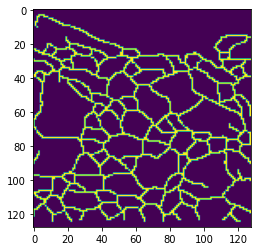

In [173]:
plt.imshow(img)

In [174]:
imageio.imsave('/localhome/asa420/MIAL/data/confocal-data/vess_enh_unet/atl/gt_skel/atl2_proc_skel_new.png', img)

In [188]:
for i in range(1, 17):
    try:
        analyzer_op = imageio.imread(f'/localhome/asa420/MIAL/data/sted-data/vess_enh_unet/climp/analyzer_op/ER_ce{i}.png')
        data = analyzer_op[:,:,0]
        data = data[52:1670, 52:1670]
        data = skimage.transform.resize(data, (128, 128), anti_aliasing=True)
        thr = threshold_otsu(data)
        bin_out = data > thr
        bin_out = bin_out.astype('uint8')*255
        imageio.imsave(f'/localhome/asa420/MIAL/data/sted-data/vess_enh_unet/climp/analyzer_op/resized_op/climp{i}_out.png', bin_out)
    except:
        pass